# Análisis Exploratorio de Datos (EDA) y Limpieza de Datos con Python

## Objetivos de aprendizaje

Al finalizar este notebook serás capaz de:

- Comprender qué es el Análisis Exploratorio de Datos (EDA).
- Identificar problemas comunes en los datos.
- Detectar y tratar valores faltantes.
- Detectar y eliminar registros duplicados.
- Utilizar Pandas para limpiar y preparar datos.
- Aplicar buenas prácticas de calidad de datos.
- Preparar conjuntos de datos para análisis y Machine Learning.

---


# 1. Introducción al EDA



## ¿Qué es el EDA?



El **Análisis Exploratorio de Datos (EDA - Exploratory Data Analysis)** es el proceso de examinar, resumir y visualizar datos para comprender su estructura, detectar problemas y descubrir patrones antes de realizar análisis avanzados o construir modelos predictivos.



### Objetivos del EDA

- Comprender los datos.
- Detectar errores.
- Encontrar patrones.
- Identificar anomalías.
- Evaluar la calidad de los datos.
- Generar hipótesis para análisis posteriores.

### Analogía

El EDA puede compararse con una investigación policial:

| Investigación | EDA |
|--------------|-----|
| Evidencias | Datos |
| Detective | Analista |
| Pistas | Patrones |
| Sospechosos | Variables |
| Anomalías | Valores atípicos |
| Herramientas | Python y Pandas |

---



# 2. Importación de bibliotecas


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Datos Ficticios

In [2]:
import pandas as pd
import numpy as np

datos = {
    "id": [1, 2, 3, 4, 5, 5, 7, 8, 9, 10],
    "nombre": [
        "Juan",
        "Ana",
        "Pedro",
        "María",
        "Luis",
        "Luis",
        "Carlos",
        "Sofía",
        np.nan,
        "Laura"
    ],
    "edad": [25, 30, np.nan, 28, 35, 35, 45, 29, 999, 31],
    "salario": [50000, 60000, 55000, np.nan, 70000, 70000, 80000, 62000, 5000000, 65000],
    "ciudad": [
        "Buenos Aires",
        "Córdoba",
        "Rosario",
        "Cordoba",
        np.nan,
        np.nan,
        "Mendoza",
        "Rosario",
        "Buenos Aires",
        "Cordoba"
    ]
}

df = pd.DataFrame(datos)

df

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
4,5,Luis,35.0,70000.0,NaN
5,5,Luis,35.0,70000.0,NaN
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
8,9,NaN,999.0,5000000.0,Buenos Aires
9,10,Laura,31.0,65000.0,Cordoba


In [3]:
df.to_csv('datos.csv', index=False)

# 3. Carga de datos



## Leer un archivo CSV


In [4]:
df = pd.read_csv("datos.csv")


In [5]:

## Visualizar registros

df.head()


,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
4,5,Luis,35.0,70000.0,NaN


In [6]:
df.tail()

,id,nombre,edad,salario,ciudad
5,5,Luis,35.0,70000.0,NaN
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
8,9,NaN,999.0,5000000.0,Buenos Aires
9,10,Laura,31.0,65000.0,Cordoba


In [8]:
df.sample(5)

,id,nombre,edad,salario,ciudad
9,10,Laura,31.0,65000.0,Cordoba
1,2,Ana,30.0,60000.0,Córdoba
4,5,Luis,35.0,70000.0,NaN
3,4,María,28.0,NaN,Cordoba
5,5,Luis,35.0,70000.0,NaN



## Información general


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       10 non-null     int64  
 1   nombre   9 non-null      str    
 2   edad     9 non-null      float64
 3   salario  9 non-null      float64
 4   ciudad   8 non-null      str    
dtypes: float64(2), int64(1), str(2)
memory usage: 532.0 bytes



## Estadísticas descriptivas


In [11]:
df.describe()

,id,edad,salario
count,10.000000,9.000000,9.000000e+00
mean,5.400000,139.666667,6.124444e+05
std,3.025815,322.301489,1.645357e+06
min,1.000000,25.000000,5.000000e+04
25%,3.250000,29.000000,6.000000e+04
50%,5.000000,31.000000,6.500000e+04
75%,7.750000,35.000000,7.000000e+04
max,10.000000,999.000000,5.000000e+06


# 4. Comprensión inicial de los datos

Antes de limpiar datos debemos responder:

- ¿Qué representan los datos?
- ¿De dónde provienen?
- ¿Qué variables contiene el dataset?
- ¿Existen restricciones conocidas?
- ¿Hay documentación o diccionario de datos?

---

# 5. Problemas comunes de calidad de datos

Los conjuntos de datos suelen contener:

| Problema | Ejemplo |
|-----------|----------|
| Valores faltantes | Edad vacía |
| Duplicados | Cliente repetido |
| Errores tipográficos | Argntina |
| Formatos inconsistentes | 01/01/2025 y 2025-01-01 |
| Valores inválidos | Edad = -10 |
| Outliers | Salario = 999999999 |

---

# 6. Manejo de valores faltantes

## ¿Qué son?

Son datos ausentes o desconocidos.

### Causas frecuentes

- Encuestas incompletas.
- Errores de captura.
- Fallos de sensores.
- Problemas de integración.

---


## Detectar valores faltantes

### Conteo por columna


In [12]:
df.isnull().sum()

id         0
nombre     1
edad       1
salario    1
ciudad     2
dtype: int64


### Porcentaje de faltantes


In [14]:
print(len(df))

(df.isnull().sum() / len(df)) * 100



10


id          0.0
nombre     10.0
edad       10.0
salario    10.0
ciudad     20.0
dtype: float64

### Filas con valores faltantes

In [15]:
df.isnull()

,id,nombre,edad,salario,ciudad
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,True,False,False
3,False,False,False,True,False
4,False,False,False,False,True
5,False,False,False,False,True
6,False,False,False,False,False
7,False,False,False,False,False
8,False,True,False,False,False
9,False,False,False,False,False


In [18]:
df.isnull().any(axis=1)

0    False
1    False
2     True
3     True
4     True
5     True
6    False
7    False
8     True
9    False
dtype: bool

In [16]:
df [ df.isnull().any(axis=1) ]

,id,nombre,edad,salario,ciudad
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
4,5,Luis,35.0,70000.0,NaN
5,5,Luis,35.0,70000.0,NaN
8,9,NaN,999.0,5000000.0,Buenos Aires



---

## Métodos para tratar valores faltantes

### 1. Eliminar filas


In [19]:
df.dropna()  # es solo una vista

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
9,10,Laura,31.0,65000.0,Cordoba


### 2. Eliminar columnas

In [20]:
df.dropna(axis=1)

,id
0,1
1,2
2,3
3,4
4,5
5,5
6,7
7,8
8,9
9,10


In [21]:
df.dropna(axis=1, how="all")

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
4,5,Luis,35.0,70000.0,NaN
5,5,Luis,35.0,70000.0,NaN
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
8,9,NaN,999.0,5000000.0,Buenos Aires
9,10,Laura,31.0,65000.0,Cordoba


In [23]:
df.dropna(axis=0, how="any")

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
9,10,Laura,31.0,65000.0,Cordoba


In [24]:
df.dropna(axis=1, thresh=2)

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
4,5,Luis,35.0,70000.0,NaN
5,5,Luis,35.0,70000.0,NaN
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
8,9,NaN,999.0,5000000.0,Buenos Aires
9,10,Laura,31.0,65000.0,Cordoba


La columna ciudad tiene 8 valores no nulos (solo filas 4 y 5 son NaN).
Como thresh=2 pide al menos 2 valores no nulos para conservar la columna, ciudad cumple ampliamente con ese criterio.
Por eso, la columna ciudad no se elimina.

In [25]:
df.dropna(axis=1, thresh=9)

,id,nombre,edad,salario
0,1,Juan,25.0,50000.0
1,2,Ana,30.0,60000.0
2,3,Pedro,NaN,55000.0
3,4,María,28.0,NaN
4,5,Luis,35.0,70000.0
5,5,Luis,35.0,70000.0
6,7,Carlos,45.0,80000.0
7,8,Sofía,29.0,62000.0
8,9,NaN,999.0,5000000.0
9,10,Laura,31.0,65000.0


In [26]:
data = {
    'A': [1, np.nan, 3],
    'B': [np.nan, np.nan, 3],
    'C': [1, 2, 3]
}

df_1 = pd.DataFrame(data)
print("Antes:")
print(df_1)

df_2 = df_1.dropna(axis=1, thresh=2)
print("Después:")
print(df_2)

Antes:
     A    B  C
0  1.0  NaN  1
1  NaN  NaN  2
2  3.0  3.0  3
Después:
     A  C
0  1.0  1
1  NaN  2
2  3.0  3


### 3. Imputar con la media

Es el promedio aritmético de un conjunto de datos. Se calcula sumando todos los valores y dividiendo esa suma por la cantidad total de datos. 

Representa un valor central típico del conjunto.

In [27]:
edad_media = df["edad"].mean()
print(f"la edad promedio del datasets es de {edad_media:.3f}")

la edad promedio del datasets es de 139.667


In [28]:
df["edad"].fillna(df["edad"].mean())

0     25.000000
1     30.000000
2    139.666667
3     28.000000
4     35.000000
5     35.000000
6     45.000000
7     29.000000
8    999.000000
9     31.000000
Name: edad, dtype: float64

In [29]:
df

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
4,5,Luis,35.0,70000.0,NaN
5,5,Luis,35.0,70000.0,NaN
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
8,9,NaN,999.0,5000000.0,Buenos Aires
9,10,Laura,31.0,65000.0,Cordoba


### 4. Imputar con la mediana

La mediana es el valor que se encuentra en el centro de un conjunto de datos ordenados, dividiendo el conjunto en dos partes iguales. 

Es una medida de tendencia central que representa el punto medio, y es especialmente útil cuando hay valores extremos o datos sesgados.

In [31]:
df["edad"].fillna(df["edad"].median())

0     25.0
1     30.0
2     31.0
3     28.0
4     35.0
5     35.0
6     45.0
7     29.0
8    999.0
9     31.0
Name: edad, dtype: float64

### 5. Imputar con la moda

Es el valor que aparece con mayor frecuencia en un conjunto de datos. 

Puede haber una moda (unimodal), más de una (multimodal) o ninguna si todos los valores son únicos.

In [32]:
edad_de_moda = df["edad"].mode()
print(edad_de_moda)

0    35.0
Name: edad, dtype: float64


In [33]:
df["edad"].fillna(df["edad"].mode()[0])

0     25.0
1     30.0
2     35.0
3     28.0
4     35.0
5     35.0
6     45.0
7     29.0
8    999.0
9     31.0
Name: edad, dtype: float64

### 6. Crear categoría especial

Imputar un dato faltante con una categoría especial consiste en reemplazar los valores ausentes en una variable categórica por una nueva categoría que indique explícitamente que el dato está faltante, por ejemplo, "Desconocido" o "No especificado".

- Cómo y cuándo usar esta técnica:
  - Cuándo:
    - Cuando la variable es categórica y los datos faltantes no se pueden asumir como aleatorios o no se pueden imputar con valores existentes sin perder información. También es útil cuando la ausencia del dato puede tener un significado propio o influir en el análisis.
<br>
  - Cómo:
    - Se crea una nueva categoría especial para los valores faltantes y se reemplazan los NaN por esa categoría. Por ejemplo, en pandas:

In [34]:
df

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
4,5,Luis,35.0,70000.0,NaN
5,5,Luis,35.0,70000.0,NaN
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
8,9,NaN,999.0,5000000.0,Buenos Aires
9,10,Laura,31.0,65000.0,Cordoba


In [35]:
df["ciudad"].fillna("Extanjero")

0    Buenos Aires
1         Córdoba
2         Rosario
3         Cordoba
4       Extanjero
5       Extanjero
6         Mendoza
7         Rosario
8    Buenos Aires
9         Cordoba
Name: ciudad, dtype: str


---

## Comparación de técnicas

| Método | Ventajas | Desventajas |
|----------|----------|----------|
| Eliminar | Simple | Pierde información |
| Media | Fácil | Sensible a outliers |
| Mediana | Robusta | Puede ocultar variabilidad |
| Moda | Ideal para categorías | Puede introducir sesgo |
| Categoría especial | Conserva datos | Puede agregar ruido |

---


# 7. Manejo de valores duplicados

## ¿Qué son?

Son registros repetidos dentro de un conjunto de datos.

### Ejemplo

| ID | Nombre | Edad |
|----|---------|------|
| 1 | Juan | 30 |
| 2 | Ana | 25 |
| 1 | Juan | 30 |

---

## Detectar duplicados

### Verificar duplicados

In [36]:
df.duplicated()

0    False
1    False
2    False
3    False
4    False
5     True
6    False
7    False
8    False
9    False
dtype: bool

### Contar duplicados

In [37]:
df.duplicated().sum()

np.int64(1)

### Mostrar filas duplicadas

In [38]:
df[df.duplicated()]

,id,nombre,edad,salario,ciudad
5,5,Luis,35.0,70000.0,NaN


### Eliminar duplicados

### Mantener la primera ocurrencia

```python
df = df.drop_duplicates()
```

o

```python
df = df.drop_duplicates(keep="first")
```

In [39]:
df.drop_duplicates()

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
4,5,Luis,35.0,70000.0,NaN
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
8,9,NaN,999.0,5000000.0,Buenos Aires
9,10,Laura,31.0,65000.0,Cordoba


In [40]:
df.drop_duplicates(keep="first")

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
4,5,Luis,35.0,70000.0,NaN
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
8,9,NaN,999.0,5000000.0,Buenos Aires
9,10,Laura,31.0,65000.0,Cordoba


Mantener la última ocurrencia


In [41]:
df.drop_duplicates(keep="last")

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
5,5,Luis,35.0,70000.0,NaN
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
8,9,NaN,999.0,5000000.0,Buenos Aires
9,10,Laura,31.0,65000.0,Cordoba


Eliminar todas las ocurrencias

In [99]:
df.drop_duplicates(keep=False)

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
8,9,NaN,999.0,5000000.0,Buenos Aires
9,10,Laura,31.0,65000.0,Cordoba


In [45]:
df.ciudad.value_counts()

ciudad
Buenos Aires    2
Rosario         2
Cordoba         2
Córdoba         1
Mendoza         1
Name: count, dtype: int64

### Buscar duplicados por columnas específicas

In [42]:
df.ciudad

0    Buenos Aires
1         Córdoba
2         Rosario
3         Cordoba
4             NaN
5             NaN
6         Mendoza
7         Rosario
8    Buenos Aires
9         Cordoba
Name: ciudad, dtype: str

In [43]:
df.duplicated(subset=["ciudad"])

0    False
1    False
2    False
3    False
4    False
5     True
6    False
7     True
8     True
9     True
dtype: bool

### Eliminar duplicados por columna

In [104]:
df.drop_duplicates(subset=["ciudad"])

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
4,5,Luis,35.0,70000.0,NaN
6,7,Carlos,45.0,80000.0,Mendoza


# 8. Transformación de datos

La transformación permite adaptar los datos para el análisis.

In [46]:
df_copy = df.copy() 
df_copy

,id,nombre,edad,salario,ciudad
0,1,Juan,25.0,50000.0,Buenos Aires
1,2,Ana,30.0,60000.0,Córdoba
2,3,Pedro,NaN,55000.0,Rosario
3,4,María,28.0,NaN,Cordoba
4,5,Luis,35.0,70000.0,NaN
5,5,Luis,35.0,70000.0,NaN
6,7,Carlos,45.0,80000.0,Mendoza
7,8,Sofía,29.0,62000.0,Rosario
8,9,NaN,999.0,5000000.0,Buenos Aires
9,10,Laura,31.0,65000.0,Cordoba


## Crear nuevas columnas

In [47]:
from datetime import datetime

In [51]:
hoy = datetime.now()
hoy

datetime.datetime(2026, 6, 22, 21, 1, 13, 333895)

In [52]:
año = hoy.year
año

2026

In [53]:
type(año)

int

In [54]:
df_copy["año"] = año - df["edad"]
display(df_copy)

,id,nombre,edad,salario,ciudad,año
0,1,Juan,25.0,50000.0,Buenos Aires,2001.0
1,2,Ana,30.0,60000.0,Córdoba,1996.0
2,3,Pedro,NaN,55000.0,Rosario,NaN
3,4,María,28.0,NaN,Cordoba,1998.0
4,5,Luis,35.0,70000.0,NaN,1991.0
5,5,Luis,35.0,70000.0,NaN,1991.0
6,7,Carlos,45.0,80000.0,Mendoza,1981.0
7,8,Sofía,29.0,62000.0,Rosario,1997.0
8,9,NaN,999.0,5000000.0,Buenos Aires,1027.0
9,10,Laura,31.0,65000.0,Cordoba,1995.0


## Convertir tipos de datos

In [55]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       10 non-null     int64  
 1   nombre   9 non-null      str    
 2   edad     9 non-null      float64
 3   salario  9 non-null      float64
 4   ciudad   8 non-null      str    
 5   año      9 non-null      float64
dtypes: float64(3), int64(1), str(2)
memory usage: 612.0 bytes


In [56]:
df_copy["año"] = pd.to_datetime(df_copy["año"])

In [57]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   id       10 non-null     int64         
 1   nombre   9 non-null      str           
 2   edad     9 non-null      float64       
 3   salario  9 non-null      float64       
 4   ciudad   8 non-null      str           
 5   año      9 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), str(2)
memory usage: 612.0 bytes


In [64]:
hoy = datetime.now()

In [65]:
hoy.timestamp()

1782173134.718102

In [123]:
df_copy

,id,nombre,edad,salario,ciudad,año
0,1,Juan,25.0,50000.0,Buenos Aires,1970-01-01 00:00:00.000002001
1,2,Ana,30.0,60000.0,Córdoba,1970-01-01 00:00:00.000001996
2,3,Pedro,NaN,55000.0,Rosario,NaT
3,4,María,28.0,NaN,Cordoba,1970-01-01 00:00:00.000001998
4,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991
5,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991
6,7,Carlos,45.0,80000.0,Mendoza,1970-01-01 00:00:00.000001981
7,8,Sofía,29.0,62000.0,Rosario,1970-01-01 00:00:00.000001997
8,9,NaN,999.0,5000000.0,Buenos Aires,1970-01-01 00:00:00.000001027
9,10,Laura,31.0,65000.0,Cordoba,1970-01-01 00:00:00.000001995


## Renombrar columnas

In [66]:
df_copy.columns 

Index(['id', 'nombre', 'edad', 'salario', 'ciudad', 'año'], dtype='str')

In [67]:
df_copy.rename(columns={"edad":"Edad"}, inplace=True)
df_copy.columns

Index(['id', 'nombre', 'Edad', 'salario', 'ciudad', 'año'], dtype='str')

# 9. Validación de datos

Después de limpiar los datos es necesario verificar:

- Exactitud.
- Consistencia.
- Integridad.
- Completitud.

### Ejemplos

```python
df.info()
```

```python
df.describe()
```

```python
df.isnull().sum()
```

```python
df.duplicated().sum()
```

# 10. Visualización rápida para detectar problemas

## Histograma

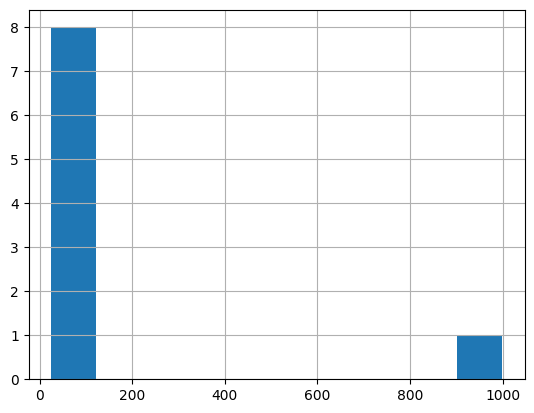

In [127]:
df["edad"].hist()
plt.show()


## Diagrama de caja

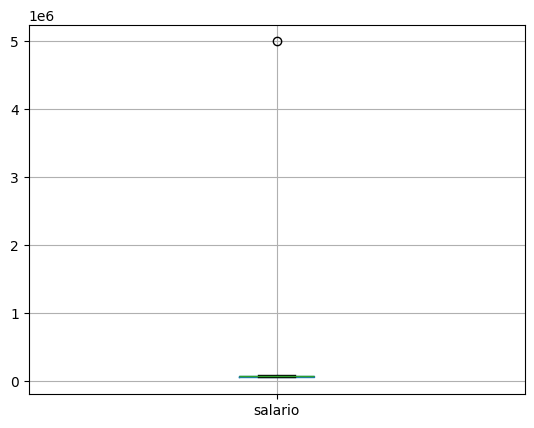

In [128]:
df.boxplot(column="salario")
plt.show()

Estos gráficos ayudan a detectar:

- Valores extremos.
- Distribuciones anómalas.
- Errores de captura.

---

# 11. Detección y Tratamiento de Valores Atípicos (Outliers) en Python

## ¿Qué son los valores atípicos?

Los **valores atípicos** (*outliers*) son observaciones que se alejan significativamente del comportamiento general de los datos.

Representan valores extremadamente altos o bajos respecto al resto del conjunto de datos.

In [133]:
df_copy

,id,nombre,Edad,salario,ciudad,año
0,1,Juan,25.0,50000.0,Buenos Aires,1970-01-01 00:00:00.000002001
1,2,Ana,30.0,60000.0,Córdoba,1970-01-01 00:00:00.000001996
2,3,Pedro,NaN,55000.0,Rosario,NaT
3,4,María,28.0,NaN,Cordoba,1970-01-01 00:00:00.000001998
4,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991
5,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991
6,7,Carlos,45.0,80000.0,Mendoza,1970-01-01 00:00:00.000001981
7,8,Sofía,29.0,62000.0,Rosario,1970-01-01 00:00:00.000001997
8,9,NaN,999.0,5000000.0,Buenos Aires,1970-01-01 00:00:00.000001027
9,10,Laura,31.0,65000.0,Cordoba,1970-01-01 00:00:00.000001995


In [131]:
df_copy.loc[8].salario

np.float64(5000000.0)

In [134]:
df_copy.loc[8].Edad

np.float64(999.0)

## ¿Por qué aparecen los outliers?

### 1. Errores de medición

Problemas durante la captura de datos.

#### Ejemplo

```text
Temperatura real: 25°C
Temperatura registrada: 250°C
```

---

### 2. Errores de carga

Errores humanos al ingresar información.

#### Ejemplo

```text
Edad correcta: 35
Edad ingresada: 350
```

---

### 3. Eventos reales

Algunos outliers representan situaciones legítimas.

### Ejemplo

```text
Ingresos de una celebridad
```

o

```text
Ganancias extraordinarias de una empresa
```

---

## ¿Por qué son importantes?

Los outliers pueden:

- Distorsionar promedios.
- Alterar desviaciones estándar.
- Sesgar análisis estadísticos.
- Impactar modelos de Machine Learning.
- Dificultar la visualización de datos.

## Detección visual de outliers

### Boxplot

Un boxplot muestra:

- Mínimo
- Primer cuartil (Q1)
- Mediana
- Tercer cuartil (Q3)
- Máximo
- Valores atípicos

Los outliers aparecen como puntos fuera de los "bigotes".

,valores
count,103.000000
mean,53.784544
std,21.055201
min,24.470102
25%,43.934141
50%,51.269121
75%,58.209633
max,170.000000


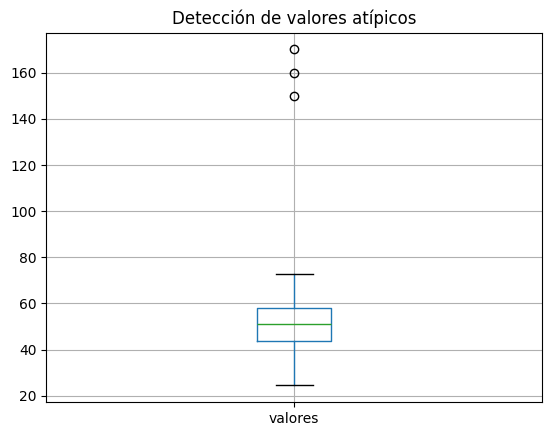

In [138]:
# Datos: distribución normal + valores atípicos
np.random.seed(0)
data = {'valores': np.append(np.random.normal(50, 10, 100), [150, 160, 170])}
df = pd.DataFrame(data)
display(df.describe())
# Visualizar con boxplot
df.boxplot(column=['valores'])
plt.title("Detección de valores atípicos")
plt.show()

## Deteccion Analitica

## Método 1: Z-Score

### Concepto

El Z-Score mide cuántas desviaciones estándar se encuentra un dato respecto de la media.

### Fórmula

$$
Z = \frac{x - \mu}{\sigma}
$$

Donde:

- $x$ = valor observado
- $\mu$ = media
- $\sigma$ = desviación estándar

In [135]:
from scipy.stats import zscore

In [142]:
df_copy

,id,nombre,Edad,salario,ciudad,año
0,1,Juan,25.0,50000.0,Buenos Aires,1970-01-01 00:00:00.000002001
1,2,Ana,30.0,60000.0,Córdoba,1970-01-01 00:00:00.000001996
2,3,Pedro,NaN,55000.0,Rosario,NaT
3,4,María,28.0,NaN,Cordoba,1970-01-01 00:00:00.000001998
4,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991
5,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991
6,7,Carlos,45.0,80000.0,Mendoza,1970-01-01 00:00:00.000001981
7,8,Sofía,29.0,62000.0,Rosario,1970-01-01 00:00:00.000001997
8,9,NaN,999.0,5000000.0,Buenos Aires,1970-01-01 00:00:00.000001027
9,10,Laura,31.0,65000.0,Cordoba,1970-01-01 00:00:00.000001995


In [146]:
df_copy.at[2,"Edad"] = 35


In [153]:
df_copy['z_score_edad'] = zscore(df_copy['Edad'])
df_copy

,id,nombre,Edad,salario,ciudad,año,z_score_edad
0,1,Juan,25.0,50000.0,Buenos Aires,1970-01-01 00:00:00.000002001,-0.359335
1,2,Ana,30.0,60000.0,Córdoba,1970-01-01 00:00:00.000001996,-0.342092
2,3,Pedro,35.0,55000.0,Rosario,NaT,-0.324850
3,4,María,28.0,NaN,Cordoba,1970-01-01 00:00:00.000001998,-0.348989
4,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991,-0.324850
5,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991,-0.324850
6,7,Carlos,45.0,80000.0,Mendoza,1970-01-01 00:00:00.000001981,-0.290365
7,8,Sofía,29.0,62000.0,Rosario,1970-01-01 00:00:00.000001997,-0.345541
8,9,NaN,999.0,5000000.0,Buenos Aires,1970-01-01 00:00:00.000001027,2.999514
9,10,Laura,31.0,65000.0,Cordoba,1970-01-01 00:00:00.000001995,-0.338644


In [154]:
df_copy.at[3,"salario"] = df_copy.salario.median()
df_copy

,id,nombre,Edad,salario,ciudad,año,z_score_edad
0,1,Juan,25.0,50000.0,Buenos Aires,1970-01-01 00:00:00.000002001,-0.359335
1,2,Ana,30.0,60000.0,Córdoba,1970-01-01 00:00:00.000001996,-0.342092
2,3,Pedro,35.0,55000.0,Rosario,NaT,-0.324850
3,4,María,28.0,65000.0,Cordoba,1970-01-01 00:00:00.000001998,-0.348989
4,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991,-0.324850
5,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991,-0.324850
6,7,Carlos,45.0,80000.0,Mendoza,1970-01-01 00:00:00.000001981,-0.290365
7,8,Sofía,29.0,62000.0,Rosario,1970-01-01 00:00:00.000001997,-0.345541
8,9,NaN,999.0,5000000.0,Buenos Aires,1970-01-01 00:00:00.000001027,2.999514
9,10,Laura,31.0,65000.0,Cordoba,1970-01-01 00:00:00.000001995,-0.338644


In [155]:
df_copy['z_score_salario'] = zscore(df_copy['salario'])
df_copy

,id,nombre,Edad,salario,ciudad,año,z_score_edad,z_score_salario
0,1,Juan,25.0,50000.0,Buenos Aires,1970-01-01 00:00:00.000002001,-0.359335,-0.342858
1,2,Ana,30.0,60000.0,Córdoba,1970-01-01 00:00:00.000001996,-0.342092,-0.336105
2,3,Pedro,35.0,55000.0,Rosario,NaT,-0.324850,-0.339481
3,4,María,28.0,65000.0,Cordoba,1970-01-01 00:00:00.000001998,-0.348989,-0.332728
4,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991,-0.324850,-0.329352
5,5,Luis,35.0,70000.0,NaN,1970-01-01 00:00:00.000001991,-0.324850,-0.329352
6,7,Carlos,45.0,80000.0,Mendoza,1970-01-01 00:00:00.000001981,-0.290365,-0.322599
7,8,Sofía,29.0,62000.0,Rosario,1970-01-01 00:00:00.000001997,-0.345541,-0.334754
8,9,NaN,999.0,5000000.0,Buenos Aires,1970-01-01 00:00:00.000001027,2.999514,2.999957
9,10,Laura,31.0,65000.0,Cordoba,1970-01-01 00:00:00.000001995,-0.338644,-0.332728


### 3. Interpretación
El z-score indica cuántas desviaciones estándar está un valor respecto a la media.
Valores con z-score > 3 o < -3 suelen considerarse atípicos (outliers).

## Método 2: IQR (Rango Intercuartílico)

### Concepto

El IQR mide la dispersión del 50% central de los datos.

### Fórmula

$$
IQR = Q3 - Q1
$$

Donde:

- Q1 = Primer cuartil
- Q3 = Tercer cuartil

---

## Límites para detectar outliers

### Límite inferior

$$
Q1 - 1.5 \times IQR
$$

### Límite superior

$$
Q3 + 1.5 \times IQR
$$

Todo valor fuera de esos límites se considera atípico.

---

# 12. Flujo completo de limpieza de datos

```text
Datos originales
        ↓
Comprensión de los datos
        ↓
Análisis exploratorio (EDA)
        ↓
Detección de valores faltantes
        ↓
Tratamiento de faltantes
        ↓
Detección de duplicados
        ↓
Eliminación de duplicados
        ↓
Transformación de datos
        ↓
Validación
        ↓
Visualización
        ↓
Datos listos para análisis o Machine Learning
```

---

# 12. Buenas prácticas

✅ Comprender el contexto de los datos antes de modificarlos.

✅ Documentar todas las transformaciones realizadas.

✅ Analizar el impacto de eliminar registros.

✅ Evitar imputaciones sin justificación.

✅ Verificar la calidad de los datos después de cada cambio.

✅ Utilizar identificadores únicos para prevenir duplicados.

✅ Automatizar procesos de limpieza cuando sea posible.

---

# 13. Checklist de Data Cleaning

## Valores faltantes

- [ ] Identificados
- [ ] Cuantificados
- [ ] Tratados adecuadamente

## Duplicados

- [ ] Detectados
- [ ] Analizados
- [ ] Eliminados o corregidos

## Consistencia

- [ ] Formatos uniformes
- [ ] Tipos de datos correctos
- [ ] Valores válidos

## Validación

- [ ] Sin duplicados
- [ ] Sin faltantes críticos
- [ ] Estadísticas coherentes

---

# Resumen Final

El proceso de limpieza de datos es una etapa fundamental dentro del EDA. Los valores faltantes, registros duplicados, inconsistencias y errores pueden afectar gravemente los resultados de un análisis o de un modelo de Machine Learning.

Utilizando herramientas como **Pandas**, es posible detectar, corregir y validar estos problemas, garantizando que los datos sean confiables, consistentes y aptos para la toma de decisiones basada en datos.

Pregunta

### Escenario: Está trabajando con un conjunto de datos que contiene información sobre las compras de los clientes. El conjunto de datos tiene algunos problemas: formatos de fecha inconsistentes, valores perdidos en la columna "Edad" y precios almacenados como texto en lugar de números.

### Pregunta Stem: ¿Cómo puede ayudarle la librería Pandas a resolver estos problemas de calidad de datos? Seleccione la mejor respuesta.


- pandas puede visualizar directamente los datos, resaltando las incoherencias y los errores.
- pandas puede generar automáticamente datos sintéticos para reemplazar los valores de "Edad" que faltan.
- pandas puede utilizarse para entrenar un modelo de aprendizaje automático que prediga los valores correctos para los datos que faltan.
- **pandas proporciona funciones para convertir tipos de datos, manejar valores perdidos y estandarizar formatos.**


> Correcto! Pandas ofrece una amplia gama de herramientas para la limpieza y transformación de datos, incluyendo funciones para abordar los problemas descritos. 